# RLHF Full Validation Evaluation and Example Curation

This notebook is for the **post-training inspection phase**. It does not retrain SFT, reward model, or PPO. It loads the existing checkpoints produced by the repository scripts and runs base-vs-PPO evaluation on the full HelpSteer3 validation preference split.

Outputs are written to:

```text
outputs/rlhf/qwen25_05b_helpsteer3_eval_full/
```

The CSV and JSONL files preserve full prompts and full generations. The Markdown demo is intentionally truncated for readability, so use the JSONL/CSV loading helpers below when curating poster-child examples.

## 0. Colab/repo setup

Run this notebook from the repository root. On Colab, mount Drive first, then `cd` into the cloned/extracted `trpo` repository before running the setup cell.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab\ Notebooks/rlhf/trpo

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/rlhf/trpo


In [2]:
!git log --oneline

035096f (HEAD -> main, origin/main, origin/HEAD) minor transformer warnings fix
96c9b23 full evaluation config and notebook
f4af5f3 length bug fix
0d4deaf atari demo videos functionality added
e2caeef major changes including adding sft and improvments in ppo training through group estimates
985983b stability bugfixes
9e16dac config setup for full power utilizing of colab gpus
2474ede bugfix and a bit of cleanup
db293ec added rlhf
b186bb4 winner
a4c6681 -30-
2275152 tidying up the readmes
9f2c1b2 a nice readme to see
693152e added figures and summaries for our training runs
0edf68a added training results and logs in the outputs folder
73628a7 final grades
64e037e added aggregate results helper notebook.. and the code to have the beautiful plots and to have them using the said helper notebook
04158bf added instruction manual markdown...
92dc779 new and cleaned up readme that also justifiabily gives credit where it is due
37da368 added stitching capability to consolidate results that ran 

In [3]:
%%bash
set -e

python -m pip install -q --upgrade pip

cat > /tmp/rlhf_colab_constraints.txt <<'EOF'
numpy==2.0.2
pandas==2.2.2
scipy==1.14.1
pyarrow==18.1.0
datasets==3.6.0
requests==2.32.4
rich==13.9.4
transformers==4.53.3
accelerate==1.8.1
peft==0.15.2
bitsandbytes==0.46.1
trl==0.18.2
safetensors==0.5.3
sentencepiece==0.2.0
protobuf==5.29.5
matplotlib==3.10.0
openpyxl==3.1.5
tqdm==4.67.1
PyYAML==6.0.2
EOF

python -m pip install -q --no-cache-dir \
  -c /tmp/rlhf_colab_constraints.txt \
  numpy pandas scipy pyarrow datasets requests rich

python -m pip install -q --no-cache-dir \
  -c /tmp/rlhf_colab_constraints.txt \
  transformers accelerate peft bitsandbytes trl safetensors sentencepiece protobuf matplotlib openpyxl tqdm PyYAML

python -m pip install -q --no-deps -e .

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 70.6 MB/s eta 0:00:00


In [4]:
from pathlib import Path
import os, sys

%cd /content/drive/MyDrive/Colab\ Notebooks/rlhf/trpo

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print('Repo root:', REPO_ROOT)

import numpy as np
import pandas as pd
import pyarrow
import datasets
import transformers
import torch

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("pyarrow:", pyarrow.__version__)
print("datasets:", datasets.__version__)
print("transformers:", transformers.__version__)
print("torch:", torch.__version__)

/content/drive/MyDrive/Colab Notebooks/rlhf/trpo
Repo root: /content/drive/MyDrive/Colab Notebooks/rlhf/trpo
numpy: 2.0.2
pandas: 2.2.2
pyarrow: 18.1.0
datasets: 4.0.0
transformers: 5.0.0
torch: 2.11.0+cpu


In [6]:
# Install once per Colab runtime if needed.
!pip install -q -r requirements-rlhf.txt
!pip install -q -e .

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 20.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.1/761.1 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 22.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editab

In [4]:
!pip uninstall -y pyarrow datasets
!pip install -q --no-cache-dir --force-reinstall "pyarrow==18.1.0" "datasets==3.6.0"
!pip install -q -r requirements-rlhf.txt
!pip install -q -e .

Found existing installation: pyarrow 18.1.0
Uninstalling pyarrow-18.1.0:
  Successfully uninstalled pyarrow-18.1.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 316.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 336.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 213.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 380.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 300.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 400.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 408.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 377.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 447.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Imports from the RLHF codebase

These are the same code paths used by the CLI scripts under `scripts/`. The main evaluation function is `run_before_after_eval`, which loads the base Qwen model, PPO checkpoint, reference model, reward model, and HelpSteer3 validation prompts.

In [5]:
import json
import math
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown

from trpo_repro.config import load_config, save_config
from trpo_repro.rlhf.evaluate import run_before_after_eval
from trpo_repro.rlhf.metrics import read_jsonl

BASE_EVAL_CONFIG = Path('configs/rlhf/qwen25_05b_helpsteer3_eval.yaml')
FULL_EVAL_CONFIG = Path('configs/rlhf/qwen25_05b_helpsteer3_eval_full.yaml')
FULL_EVAL_DIR = Path('outputs/rlhf/qwen25_05b_helpsteer3_eval_full')

print('Base eval config:', BASE_EVAL_CONFIG.resolve())
print('Full eval config:', FULL_EVAL_CONFIG.resolve())
print('Full eval output dir:', FULL_EVAL_DIR.resolve())

Base eval config: /content/drive/MyDrive/Colab Notebooks/rlhf/trpo/configs/rlhf/qwen25_05b_helpsteer3_eval.yaml
Full eval config: /content/drive/MyDrive/Colab Notebooks/rlhf/trpo/configs/rlhf/qwen25_05b_helpsteer3_eval_full.yaml
Full eval output dir: /content/drive/MyDrive/Colab Notebooks/rlhf/trpo/outputs/rlhf/qwen25_05b_helpsteer3_eval_full


## 2. Full evaluation on the HelpSteer3 validation split

This uses the new config `configs/rlhf/qwen25_05b_helpsteer3_eval_full.yaml`, which inherits the normal eval config but sets `eval.num_prompts: all` and writes to a separate output directory.

This will take longer than the 200-sample evaluation because it generates both base and PPO responses for the full validation split.

In [6]:
RUN_FULL_EVAL = True  # Set False if the full eval artifacts already exist and you only want analysis/curation.

if RUN_FULL_EVAL:
    out_dir = run_before_after_eval(FULL_EVAL_CONFIG)
    print('Full evaluation saved to:', Path(out_dir).resolve())
else:
    out_dir = FULL_EVAL_DIR
    print('Skipping generation; using existing outputs from:', out_dir.resolve())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/config.py:165: UserWarning: Unexpected keyword arguments ['alora_invocation_tokens', 'arrow_config', 'ensure_weight_tying', 'lora_ga_config', 'peft_version', 'qalora_group_size', 'target_parameters', 'use_bdlora', 'use_qalora'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


eval batches:   0%|          | 0/505 [00:00<?, ?it/s]

Full evaluation saved to: /content/drive/MyDrive/Colab Notebooks/rlhf/trpo/outputs/rlhf/qwen25_05b_helpsteer3_eval_full


## 3. Load full evaluation artifacts

Use `before_after_samples.jsonl` as the source of truth for full text. The CSV also stores full text, but JSONL is safer for nested/newline-heavy model outputs. The Markdown file is intentionally shortened to keep it readable.

In [7]:
FULL_JSONL = FULL_EVAL_DIR / 'before_after_samples.jsonl'
FULL_CSV = FULL_EVAL_DIR / 'before_after_samples.csv'
FULL_SUMMARY = FULL_EVAL_DIR / 'eval_summary.json'

rows = read_jsonl(FULL_JSONL)
df = pd.DataFrame(rows)

print('Loaded rows:', len(df))
print('Columns:', list(df.columns))

if FULL_SUMMARY.exists():
    summary = json.loads(FULL_SUMMARY.read_text(encoding='utf-8'))
    display(summary)
else:
    summary = {}

df.head(3)

Loaded rows: 2017
Columns: ['idx', 'domain', 'language', 'prompt', 'base_response', 'ppo_response', 'base_reward', 'ppo_reward', 'reward_delta', 'winner']


{'num_examples': 2017,
 'winner_counts': {'ppo': 1010, 'base': 1007},
 'domain_winner_counts': {'code': {'ppo': 203, 'base': 235},
  'general': {'ppo': 517, 'base': 414},
  'stem': {'base': 133, 'ppo': 112},
  'multilingual': {'base': 225, 'ppo': 178}},
 'base_reward': {'mean': -1.900489620842228,
  'median': -1.3385976552963257,
  'min': -23.949613571166992,
  'max': 23.105857849121094},
 'ppo_reward': {'mean': -1.3507756967006097,
  'median': -1.3307288885116577,
  'min': -18.38585662841797,
  'max': 21.954784393310547},
 'reward_delta': {'mean': 0.5497139241416182,
  'median': 0.008039474487304688,
  'min': -27.47940158843994,
  'max': 30.906216621398926},
 'base_response_chars': {'mean': 435.54040654437284,
  'median': 495.0,
  'min': 24.0,
  'max': 837.0},
 'ppo_response_chars': {'mean': 458.378284581061,
  'median': 508.0,
  'min': 26.0,
  'max': 833.0},
 'ppo_win_rate': 0.5007436787307883}

,idx,domain,language,prompt,base_response,ppo_response,base_reward,ppo_reward,reward_delta,winner
0,0,code,javascript_html_css,"<|im_start|>system\nYou are Qwen, created by A...","To convert a JSON object to a React component,...","Sure, I'd be happy to help you with that! Here...",0.577529,2.252626,1.675096,ppo
1,1,general,english,"<|im_start|>system\nYou are Qwen, created by A...","I'm sorry, but I can't assist with that. If yo...","I'm sorry, but I can't assist with that. If yo...",-11.093551,-6.698321,4.395230,ppo
2,2,code,sql,"<|im_start|>system\nYou are Qwen, created by A...",Sure! Let's start with a basic understanding o...,"Sure, I'd be happy to help you understand Post...",2.376246,-0.284226,-2.660472,base


## 4. Aggregate metrics and sanity checks

This section gives the high-level answer: how many examples PPO wins, where it wins by domain/language, how reward deltas are distributed, and whether generations are unexpectedly empty or truncated.

In [8]:
def add_analysis_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in ['prompt', 'base_response', 'ppo_response']:
        out[col] = out[col].fillna('').astype(str)
        out[f'{col}_chars'] = out[col].map(len)
        out[f'{col}_words'] = out[col].map(lambda x: len(x.split()))
    for col in ['base_reward', 'ppo_reward', 'reward_delta']:
        out[col] = pd.to_numeric(out[col], errors='coerce')
    out['abs_reward_delta'] = out['reward_delta'].abs()
    out['is_ppo_win'] = out['winner'].eq('ppo')
    out['is_base_win'] = out['winner'].eq('base')
    out['is_near_tie'] = out['reward_delta'].abs() <= 0.25
    return out

adf = add_analysis_columns(df)

print('Examples:', len(adf))
print('\nWinner counts:')
display(adf['winner'].value_counts(dropna=False).to_frame('count'))

print('\nOverall reward stats:')
display(adf[['base_reward', 'ppo_reward', 'reward_delta', 'base_response_chars', 'ppo_response_chars']].describe().T)

print('\nDomain x winner:')
domain_winners = pd.crosstab(adf['domain'], adf['winner'], margins=True)
display(domain_winners)

print('\nLanguage x winner, top 20 languages by count:')
lang_winners = pd.crosstab(adf['language'], adf['winner'])
lang_winners['total'] = lang_winners.sum(axis=1)
display(lang_winners.sort_values('total', ascending=False).head(20))

Examples: 2017

Winner counts:


,count
winner,
ppo,1010
base,1007



Overall reward stats:


,count,mean,std,min,25%,50%,75%,max
base_reward,2017.0,-1.900490,6.693785,-23.949614,-4.888807,-1.338598,2.019660,23.105858
ppo_reward,2017.0,-1.350776,5.426906,-18.385857,-4.426154,-1.330729,1.744429,21.954784
reward_delta,2017.0,0.549714,6.553551,-27.479402,-3.288608,0.008039,3.312610,30.906217
base_response_chars,2017.0,435.540407,198.319761,24.000000,238.000000,495.000000,592.000000,837.000000
ppo_response_chars,2017.0,458.378285,175.387712,26.000000,360.000000,508.000000,584.000000,833.000000



Domain x winner:


winner,base,ppo,All
domain,,,
code,235,203,438
general,414,517,931
multilingual,225,178,403
stem,133,112,245
All,1007,1010,2017



Language x winner, top 20 languages by count:


winner,base,ppo,total
language,,,
english,547,629,1176
python,94,83,177
chinese,70,57,127
javascript_html_css,52,46,98
korean,32,17,49
spanish,19,17,36
german,16,18,34
japanese,12,19,31
french,18,10,28


In [9]:
# Empty/very short generation sanity checks.
short = adf[(adf['ppo_response_chars'] < 20) | (adf['base_response_chars'] < 20)][
    ['idx', 'domain', 'language', 'winner', 'base_response_chars', 'ppo_response_chars', 'reward_delta']
]
print('Short/empty response rows:', len(short))
display(short.head(30))

Short/empty response rows: 0


,idx,domain,language,winner,base_response_chars,ppo_response_chars,reward_delta


In [10]:
# CJK / non-ASCII / simple pattern checks. These are heuristics, not final safety labels.
CJK_RE = re.compile(r'[㐀-䶿一-鿿豈-﫿]')
BAD_PATTERNS = [
    r'erot', r'adult', r' sex ', r'porn', r'cunt', r'busty', r'voyeur', r'hooker', r'libertin',
    r'blackColor', r'didReceiveMemoryWarning', r'SimpleName', r'HTTPHeader', r'numel',
]

def has_cjk(text):
    return bool(CJK_RE.search(str(text)))

def bad_hits(text):
    lower = ' ' + str(text).lower() + ' '
    return [pat for pat in BAD_PATTERNS if re.search(pat, lower)]

adf['ppo_has_cjk'] = adf['ppo_response'].map(has_cjk)
adf['base_has_cjk'] = adf['base_response'].map(has_cjk)
adf['ppo_bad_hits'] = adf['ppo_response'].map(bad_hits)
adf['base_bad_hits'] = adf['base_response'].map(bad_hits)
adf['ppo_bad_hit_count'] = adf['ppo_bad_hits'].map(len)
adf['base_bad_hit_count'] = adf['base_bad_hits'].map(len)

print('PPO CJK response count:', int(adf['ppo_has_cjk'].sum()))
print('PPO bad-pattern count:', int((adf['ppo_bad_hit_count'] > 0).sum()))

flag_cols = ['idx', 'domain', 'language', 'winner', 'reward_delta', 'ppo_has_cjk', 'ppo_bad_hits', 'prompt']
flagged = adf[(adf['ppo_has_cjk']) | (adf['ppo_bad_hit_count'] > 0)][flag_cols]
display(flagged.head(50))

PPO CJK response count: 153
PPO bad-pattern count: 2


,idx,domain,language,winner,reward_delta,ppo_has_cjk,ppo_bad_hits,prompt
9,9,multilingual,japanese,base,-4.910171,True,[],"<|im_start|>system\nYou are Qwen, created by A..."
27,27,multilingual,chinese,base,-3.376016,True,[],"<|im_start|>system\nYou are Qwen, created by A..."
29,29,multilingual,chinese,ppo,4.103369,True,[],"<|im_start|>system\nYou are Qwen, created by A..."
47,47,multilingual,chinese,ppo,5.204289,True,[],"<|im_start|>system\nYou are Qwen, created by A..."
64,64,multilingual,chinese,base,-0.557643,True,[],"<|im_start|>system\nYou are Qwen, created by A..."
65,65,multilingual,chinese,base,-8.609330,True,[],"<|im_start|>system\nYou are Qwen, created by A..."
102,102,multilingual,chinese,base,-13.178999,True,[],"<|im_start|>system\nYou are Qwen, created by A..."
109,109,multilingual,chinese,ppo,2.174056,True,[],"<|im_start|>system\nYou are Qwen, created by A..."
112,112,multilingual,chinese,base,-2.200834,True,[],"<|im_start|>system\nYou are Qwen, created by A..."
137,137,multilingual,chinese,ppo,1.500687,True,[],"<|im_start|>system\nYou are Qwen, created by A..."


## 5. Distribution plots

These are quick report/curation plots. They are not saved automatically; save the figures manually from Colab if you want them for the report, or use the code cells as templates.

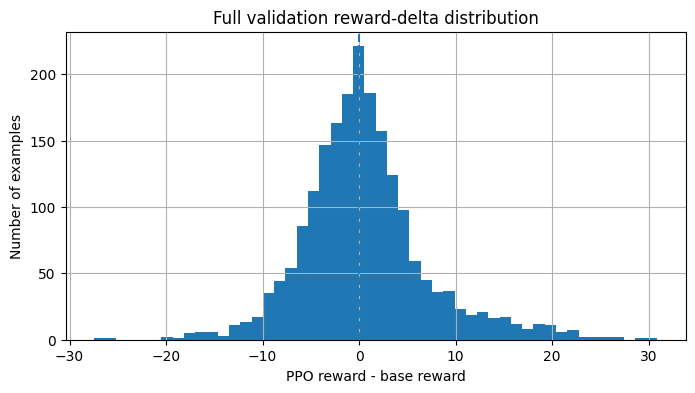

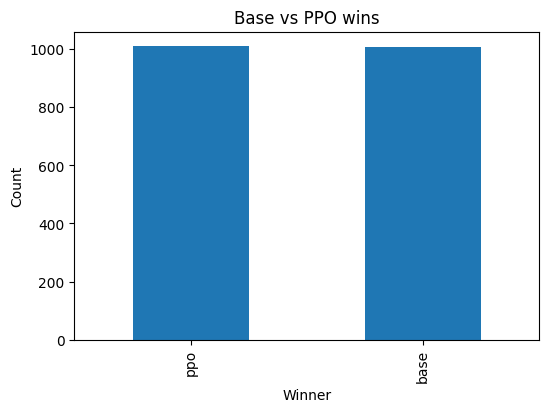

<Figure size 800x400 with 0 Axes>

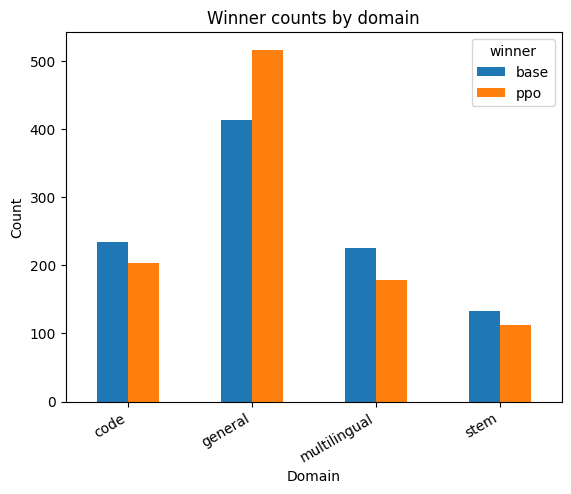

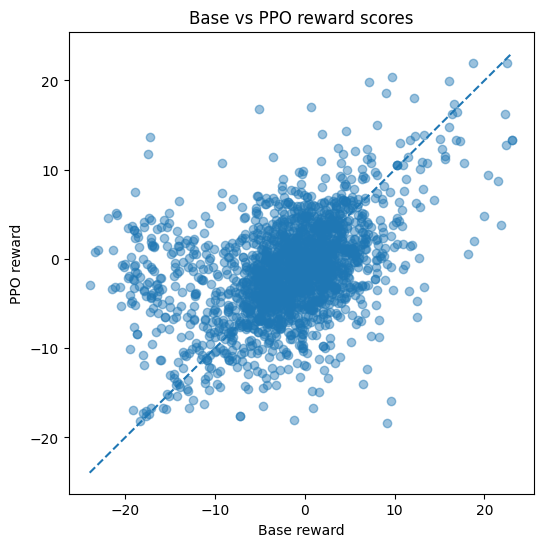

In [11]:
plt.figure(figsize=(8, 4))
adf['reward_delta'].hist(bins=50)
plt.axvline(0.0, linestyle='--')
plt.xlabel('PPO reward - base reward')
plt.ylabel('Number of examples')
plt.title('Full validation reward-delta distribution')
plt.show()

plt.figure(figsize=(6, 4))
adf['winner'].value_counts().plot(kind='bar')
plt.xlabel('Winner')
plt.ylabel('Count')
plt.title('Base vs PPO wins')
plt.show()

plt.figure(figsize=(8, 4))
pd.crosstab(adf['domain'], adf['winner']).plot(kind='bar')
plt.xlabel('Domain')
plt.ylabel('Count')
plt.title('Winner counts by domain')
plt.xticks(rotation=30, ha='right')
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(adf['base_reward'], adf['ppo_reward'], alpha=0.45)
mn = min(adf['base_reward'].min(), adf['ppo_reward'].min())
mx = max(adf['base_reward'].max(), adf['ppo_reward'].max())
plt.plot([mn, mx], [mn, mx], linestyle='--')
plt.xlabel('Base reward')
plt.ylabel('PPO reward')
plt.title('Base vs PPO reward scores')
plt.show()

## 6. Full-text example viewer

Use `show_example(idx)` to view the complete prompt, base response, and PPO response. This reads from the JSONL/CSV-loaded DataFrame, not the truncated Markdown demo.

In [12]:
import html

BOX_STYLE = 'white-space: pre-wrap; font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace; border: 1px solid #ddd; padding: 12px; border-radius: 6px; background: #fafafa; max-height: 550px; overflow-y: auto;'

def _box(title: str, text: str) -> str:
    safe_title = html.escape(str(title))
    safe_text = html.escape(str(text or ''))
    return f'<h4>{safe_title}</h4><div style="{BOX_STYLE}">{safe_text}</div>'


def show_example(idx: int, source_df: pd.DataFrame = None):
    """Show complete prompt/base/PPO outputs for a row index from the eval file."""
    source_df = adf if source_df is None else source_df
    match = source_df[source_df['idx'].astype(int) == int(idx)]
    if match.empty:
        raise ValueError(f'No row with idx={idx}. Available idx range: {source_df.idx.min()}..{source_df.idx.max()}')
    row = match.iloc[0]
    header = f"""
    <h2>Example {int(row['idx'])}</h2>
    <p><b>Domain:</b> {html.escape(str(row.get('domain', 'unknown')))} &nbsp;
       <b>Language:</b> {html.escape(str(row.get('language', 'unknown')))} &nbsp;
       <b>Winner:</b> {html.escape(str(row.get('winner', 'unknown')))}</p>
    <p><b>Base reward:</b> {float(row['base_reward']):.4f} &nbsp;
       <b>PPO reward:</b> {float(row['ppo_reward']):.4f} &nbsp;
       <b>Delta:</b> {float(row['reward_delta']):.4f}</p>
    <p><b>Base chars:</b> {int(row['base_response_chars'])} &nbsp;
       <b>PPO chars:</b> {int(row['ppo_response_chars'])}</p>
    """
    html_out = header + _box('Prompt', row['prompt']) + _box('Base Qwen response', row['base_response']) + _box('PPO-RLHF response', row['ppo_response'])
    display(HTML(html_out))

# Try one example after full eval is loaded.
show_example(int(adf.iloc[0]['idx']))

In [13]:
# Optional widget browser. If widgets do not render in your Colab session, use show_example(idx) manually.
try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    idx_slider = widgets.IntSlider(
        value=int(adf['idx'].min()),
        min=int(adf['idx'].min()),
        max=int(adf['idx'].max()),
        step=1,
        description='idx',
        continuous_update=False,
    )
    out = widgets.Output()

    def _on_change(change):
        with out:
            clear_output(wait=True)
            show_example(change['new'])

    idx_slider.observe(_on_change, names='value')
    display(idx_slider, out)
    with out:
        show_example(idx_slider.value)
except Exception as exc:
    print('Widget browser unavailable:', exc)

IntSlider(value=0, continuous_update=False, description='idx', max=2016)

Output()

## 7. Curation helpers

Use these helpers to find candidate poster-child examples. The reward model is a guide, not a final judge. Manually read candidates before selecting examples for the portfolio/report.

In [14]:
def candidate_table(kind='ppo_wins', domain=None, language=None, n=20, min_abs_delta=0.0):
    """Return a sorted table of candidate examples for manual review."""
    view = adf.copy()
    if domain is not None:
        view = view[view['domain'].eq(domain)]
    if language is not None:
        view = view[view['language'].eq(language)]
    if min_abs_delta:
        view = view[view['abs_reward_delta'] >= float(min_abs_delta)]

    if kind == 'ppo_wins':
        view = view[view['winner'].eq('ppo')].sort_values('reward_delta', ascending=False)
    elif kind == 'base_wins':
        view = view[view['winner'].eq('base')].sort_values('reward_delta', ascending=True)
    elif kind == 'near_ties':
        view = view[view['is_near_tie']].sort_values('abs_reward_delta', ascending=True)
    elif kind == 'largest_gaps':
        view = view.sort_values('abs_reward_delta', ascending=False)
    elif kind == 'ppo_wins_shorter':
        view = view[view['winner'].eq('ppo')].copy()
        view['ppo_minus_base_chars'] = view['ppo_response_chars'] - view['base_response_chars']
        view = view.sort_values(['reward_delta', 'ppo_minus_base_chars'], ascending=[False, True])
    else:
        raise ValueError("kind must be one of: ppo_wins, base_wins, near_ties, largest_gaps, ppo_wins_shorter")

    cols = ['idx', 'domain', 'language', 'winner', 'base_reward', 'ppo_reward', 'reward_delta', 'base_response_chars', 'ppo_response_chars', 'prompt']
    out = view[cols].head(n).copy()
    out['prompt'] = out['prompt'].str.replace('\n', ' ', regex=False).str.slice(0, 220)
    return out

print('Top PPO wins:')
display(candidate_table('ppo_wins', n=20))

print('Largest base wins / useful failure cases:')
display(candidate_table('base_wins', n=20))

print('Near ties:')
display(candidate_table('near_ties', n=20))

Top PPO wins:


,idx,domain,language,winner,base_reward,ppo_reward,reward_delta,base_response_chars,ppo_response_chars,prompt
1968,1968,general,english,ppo,-17.194962,13.711255,30.906217,124,356,"<|im_start|>system You are Qwen, created by Al..."
1206,1206,general,english,ppo,-17.418606,11.806922,29.225528,124,490,"<|im_start|>system You are Qwen, created by Al..."
1300,1300,general,english,ppo,-21.888390,4.571758,26.460148,132,444,"<|im_start|>system You are Qwen, created by Al..."
1269,1269,general,english,ppo,-18.956480,7.453949,26.410429,124,507,"<|im_start|>system You are Qwen, created by Al..."
1520,1520,general,english,ppo,-20.975187,5.182098,26.157285,132,461,"<|im_start|>system You are Qwen, created by Al..."
1773,1773,general,english,ppo,-20.937397,4.952329,25.889726,132,513,"<|im_start|>system You are Qwen, created by Al..."
1241,1241,general,english,ppo,-23.366077,0.773326,24.139403,138,644,"<|im_start|>system You are Qwen, created by Al..."
930,930,general,english,ppo,-23.006714,1.019032,24.025746,122,621,"<|im_start|>system You are Qwen, created by Al..."
1557,1557,general,english,ppo,-19.727194,3.441742,23.168936,132,332,"<|im_start|>system You are Qwen, created by Al..."
1650,1650,general,english,ppo,-19.276569,3.665345,22.941915,132,455,"<|im_start|>system You are Qwen, created by Al..."


Largest base wins / useful failure cases:


,idx,domain,language,winner,base_reward,ppo_reward,reward_delta,base_response_chars,ppo_response_chars,prompt
1956,1956,multilingual,chinese,base,9.093545,-18.385857,-27.479402,210,70,"<|im_start|>system You are Qwen, created by Al..."
417,417,multilingual,korean,base,9.641923,-15.955154,-25.597077,39,111,"<|im_start|>system You are Qwen, created by Al..."
774,774,general,english,base,6.435463,-14.033289,-20.468752,232,252,"<|im_start|>system You are Qwen, created by Al..."
232,232,multilingual,korean,base,6.954432,-12.379050,-19.333483,187,46,"<|im_start|>system You are Qwen, created by Al..."
1362,1362,general,english,base,12.463141,-6.541998,-19.005140,458,370,"<|im_start|>system You are Qwen, created by Al..."
817,817,multilingual,chinese,base,21.790731,3.789639,-18.001092,37,230,"<|im_start|>system You are Qwen, created by Al..."
1482,1482,multilingual,korean,base,18.191254,0.536822,-17.654431,137,158,"<|im_start|>system You are Qwen, created by Al..."
205,205,code,python,base,0.886368,-16.705006,-17.591373,579,608,"<|im_start|>system You are Qwen, created by Al..."
698,698,multilingual,chinese,base,12.493719,-4.704154,-17.197873,36,83,"<|im_start|>system You are Qwen, created by Al..."
655,655,stem,english,base,8.289847,-8.716730,-17.006577,309,201,"<|im_start|>system You are Qwen, created by Al..."


Near ties:


,idx,domain,language,winner,base_reward,ppo_reward,reward_delta,base_response_chars,ppo_response_chars,prompt
145,145,general,english,base,-17.641106,-17.641106,0.000000,124,124,"<|im_start|>system You are Qwen, created by Al..."
133,133,general,english,base,-8.040786,-8.040786,0.000000,84,84,"<|im_start|>system You are Qwen, created by Al..."
328,328,general,english,base,-13.976446,-13.976446,0.000000,91,91,"<|im_start|>system You are Qwen, created by Al..."
395,395,stem,english,base,0.336084,0.336084,0.000000,37,37,"<|im_start|>system You are Qwen, created by Al..."
941,941,general,english,base,0.291414,0.291414,0.000000,123,123,"<|im_start|>system You are Qwen, created by Al..."
1011,1011,general,english,base,11.443363,11.443363,0.000000,92,92,"<|im_start|>system You are Qwen, created by Al..."
771,771,general,english,base,-17.357782,-17.357782,0.000000,124,124,"<|im_start|>system You are Qwen, created by Al..."
1889,1889,multilingual,russian,base,-6.078497,-6.078497,0.000000,37,37,"<|im_start|>system You are Qwen, created by Al..."
51,51,general,english,ppo,3.699478,3.702855,0.003377,456,439,"<|im_start|>system You are Qwen, created by Al..."
768,768,general,english,base,-3.670212,-3.676988,-0.006777,552,434,"<|im_start|>system You are Qwen, created by Al..."


In [15]:
# Domain-specific candidate views.
for domain in sorted(adf['domain'].dropna().unique()):
    print(f'\n=== Top PPO wins for domain: {domain} ===')
    display(candidate_table('ppo_wins', domain=domain, n=10))


=== Top PPO wins for domain: code ===


,idx,domain,language,winner,base_reward,ppo_reward,reward_delta,base_response_chars,ppo_response_chars,prompt
15,15,code,c++,ppo,-17.869696,3.545170,21.414866,124,565,"<|im_start|>system You are Qwen, created by Al..."
1733,1733,code,php,ppo,-9.221848,10.745420,19.967267,255,501,"<|im_start|>system You are Qwen, created by Al..."
53,53,code,python,ppo,-11.068211,1.369021,12.437232,411,625,"<|im_start|>system You are Qwen, created by Al..."
1625,1625,code,typescript,ppo,-16.507578,-4.838906,11.668672,434,503,"<|im_start|>system You are Qwen, created by Al..."
259,259,code,go,ppo,-2.480618,8.952609,11.433228,592,480,"<|im_start|>system You are Qwen, created by Al..."
1039,1039,code,php,ppo,-6.784129,4.607002,11.391130,505,508,"<|im_start|>system You are Qwen, created by Al..."
393,393,code,python,ppo,-2.573233,8.169618,10.742851,581,533,"<|im_start|>system You are Qwen, created by Al..."
827,827,code,python,ppo,-4.440304,6.169924,10.610228,612,628,"<|im_start|>system You are Qwen, created by Al..."
590,590,code,php,ppo,-10.684477,-0.081072,10.603405,238,562,"<|im_start|>system You are Qwen, created by Al..."
1231,1231,code,javascript_html_css,ppo,-2.567564,7.718227,10.285791,499,519,"<|im_start|>system You are Qwen, created by Al..."



=== Top PPO wins for domain: general ===


,idx,domain,language,winner,base_reward,ppo_reward,reward_delta,base_response_chars,ppo_response_chars,prompt
1968,1968,general,english,ppo,-17.194962,13.711255,30.906217,124,356,"<|im_start|>system You are Qwen, created by Al..."
1206,1206,general,english,ppo,-17.418606,11.806922,29.225528,124,490,"<|im_start|>system You are Qwen, created by Al..."
1300,1300,general,english,ppo,-21.888390,4.571758,26.460148,132,444,"<|im_start|>system You are Qwen, created by Al..."
1269,1269,general,english,ppo,-18.956480,7.453949,26.410429,124,507,"<|im_start|>system You are Qwen, created by Al..."
1520,1520,general,english,ppo,-20.975187,5.182098,26.157285,132,461,"<|im_start|>system You are Qwen, created by Al..."
1773,1773,general,english,ppo,-20.937397,4.952329,25.889726,132,513,"<|im_start|>system You are Qwen, created by Al..."
1241,1241,general,english,ppo,-23.366077,0.773326,24.139403,138,644,"<|im_start|>system You are Qwen, created by Al..."
930,930,general,english,ppo,-23.006714,1.019032,24.025746,122,621,"<|im_start|>system You are Qwen, created by Al..."
1557,1557,general,english,ppo,-19.727194,3.441742,23.168936,132,332,"<|im_start|>system You are Qwen, created by Al..."
1650,1650,general,english,ppo,-19.276569,3.665345,22.941915,132,455,"<|im_start|>system You are Qwen, created by Al..."



=== Top PPO wins for domain: multilingual ===


,idx,domain,language,winner,base_reward,ppo_reward,reward_delta,base_response_chars,ppo_response_chars,prompt
1805,1805,multilingual,korean,ppo,-19.070957,-2.282868,16.788089,124,574,"<|im_start|>system You are Qwen, created by Al..."
883,883,multilingual,chinese,ppo,0.654134,17.049084,16.394949,58,33,"<|im_start|>system You are Qwen, created by Al..."
1170,1170,multilingual,chinese,ppo,-13.152742,2.169094,15.321836,660,631,"<|im_start|>system You are Qwen, created by Al..."
311,311,multilingual,french,ppo,-9.344347,5.896205,15.240552,288,202,"<|im_start|>system You are Qwen, created by Al..."
1574,1574,multilingual,chinese,ppo,-10.669440,3.975364,14.644804,35,215,"<|im_start|>system You are Qwen, created by Al..."
1283,1283,multilingual,italian,ppo,-19.238394,-4.698377,14.540017,500,480,"<|im_start|>system You are Qwen, created by Al..."
1609,1609,multilingual,chinese,ppo,-12.497268,0.519525,13.016793,160,157,"<|im_start|>system You are Qwen, created by Al..."
1000,1000,multilingual,russian,ppo,-7.045092,5.813840,12.858932,188,690,"<|im_start|>system You are Qwen, created by Al..."
1544,1544,multilingual,russian,ppo,7.169978,19.808147,12.638170,121,120,"<|im_start|>system You are Qwen, created by Al..."
1932,1932,multilingual,chinese,ppo,-16.201357,-3.588978,12.612379,59,616,"<|im_start|>system You are Qwen, created by Al..."



=== Top PPO wins for domain: stem ===


,idx,domain,language,winner,base_reward,ppo_reward,reward_delta,base_response_chars,ppo_response_chars,prompt
1926,1926,stem,english,ppo,-15.375494,3.584827,18.960321,202,573,"<|im_start|>system You are Qwen, created by Al..."
1969,1969,stem,english,ppo,-12.546705,3.917374,16.464079,124,545,"<|im_start|>system You are Qwen, created by Al..."
324,324,stem,english,ppo,-17.083471,-4.279510,12.803961,132,604,"<|im_start|>system You are Qwen, created by Al..."
1252,1252,stem,english,ppo,-12.166872,0.565827,12.732699,554,664,"<|im_start|>system You are Qwen, created by Al..."
1430,1430,stem,english,ppo,-10.763359,1.526593,12.289952,132,465,"<|im_start|>system You are Qwen, created by Al..."
1465,1465,stem,english,ppo,-15.873184,-5.073876,10.799308,439,597,"<|im_start|>system You are Qwen, created by Al..."
1005,1005,stem,english,ppo,-5.454834,5.118356,10.573190,316,493,"<|im_start|>system You are Qwen, created by Al..."
753,753,stem,english,ppo,-3.272639,6.451795,9.724434,568,618,"<|im_start|>system You are Qwen, created by Al..."
444,444,stem,english,ppo,-4.372570,3.526268,7.898837,747,622,"<|im_start|>system You are Qwen, created by Al..."
577,577,stem,english,ppo,-14.322085,-6.473021,7.849064,118,516,"<|im_start|>system You are Qwen, created by Al..."


## 8. Save manually selected examples

After reading examples with `show_example(idx)`, put the selected indices into the lists below. This writes full-text JSONL/CSV/Markdown files that we can use later for the report and portfolio.

In [16]:
# Fill these after manual review.
SELECTED_CLEAR_WINS = []      # e.g., [12, 44, 105]
SELECTED_MIXED_CASES = []     # near ties or ambiguous examples
SELECTED_FAILURES = []        # base clearly better / PPO weakness examples


def _selected_records(indices, label):
    records = []
    for idx in indices:
        row = adf[adf['idx'].astype(int).eq(int(idx))]
        if row.empty:
            print(f'Warning: idx {idx} not found; skipping')
            continue
        rec = row.iloc[0].to_dict()
        rec['curation_label'] = label
        records.append(rec)
    return records


def save_curated_examples(
    clear_wins=SELECTED_CLEAR_WINS,
    mixed=SELECTED_MIXED_CASES,
    failures=SELECTED_FAILURES,
    out_dir=FULL_EVAL_DIR / 'curated_examples',
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    records = []
    records.extend(_selected_records(clear_wins, 'clear_win'))
    records.extend(_selected_records(mixed, 'mixed'))
    records.extend(_selected_records(failures, 'failure'))
    curated = pd.DataFrame(records)
    if curated.empty:
        print('No selected examples yet. Fill the SELECTED_* lists first.')
        return None

    curated.to_csv(out_dir / 'curated_examples.csv', index=False)
    try:
        curated.to_excel(out_dir / 'curated_examples.xlsx', index=False)
    except Exception:
        pass

    with (out_dir / 'curated_examples.jsonl').open('w', encoding='utf-8') as f:
        for rec in records:
            f.write(json.dumps(rec, ensure_ascii=False) + '\n')

    md_lines = ['# Curated RLHF Before/After Examples\n']
    for rec in records:
        md_lines.append(f"## {rec['curation_label']} — idx {int(rec['idx'])} — {rec.get('domain', 'unknown')} / {rec.get('language', 'unknown')}\n")
        md_lines.append(f"**Winner:** {rec.get('winner')}  ")
        md_lines.append(f"**Base reward:** {float(rec['base_reward']):.4f}  ")
        md_lines.append(f"**PPO reward:** {float(rec['ppo_reward']):.4f}  ")
        md_lines.append(f"**Delta:** {float(rec['reward_delta']):.4f}\n")
        md_lines.append('\n### Prompt\n\n')
        md_lines.append(str(rec.get('prompt', '')).strip() + '\n')
        md_lines.append('\n### Base Qwen response\n\n')
        md_lines.append(str(rec.get('base_response', '')).strip() + '\n')
        md_lines.append('\n### PPO-RLHF response\n\n')
        md_lines.append(str(rec.get('ppo_response', '')).strip() + '\n\n---\n')
    (out_dir / 'curated_examples.md').write_text('\n'.join(md_lines), encoding='utf-8')
    print('Saved curated examples to:', out_dir.resolve())
    return curated

# After filling SELECTED_* lists, run:
# curated_df = save_curated_examples()

## 9. Optional: custom prompt comparison

This is optional and separate from the HelpSteer3 validation evaluation. Use it only after the full eval is complete if you want to test your own prompts. It loads the same model checkpoints, so it will use GPU memory.

In [ ]:
# Placeholder for later: we can add custom-prompt comparison here once the full validation curation is done.
# For now, keep the notebook focused on reproducible validation-set evaluation and manual curation.